# Урок 15.16. Теория информации: биты, энтропия, перекрёстная энтропия

**Интерактивная версия:** `lessons/lesson_15_16/web/index.html`

После урока вы сможете:

- измерять информацию в битах и натах, вычислять неожиданность $-\log_2 p$ и условную информацию;
- вычислять энтропию, понимать её как среднее число вопросов, перплексию и предел сжатия;
- строить префиксные коды и код Хаффмана, объяснять теорему Шеннона;
- вычислять условную энтропию и взаимную информацию, отличать её от корреляции;
- вычислять перекрёстную энтропию и KL-дивергенцию, связывать их с правдоподобием и PSI;
- раскладывать log-loss на предел $H(Y \mid X)$ и KL, читать кривые бустинга в битах;
- объяснять, почему прирост информации = снижение log-loss, и пользоваться неравенством Фано и MDL.

Разделы идут в том же порядке, что и 36 шагов урока (шесть блоков). Числа урока проверяются расчётом
(`assert`), ключевые — сверкой со `scipy` и scikit-learn. Случайность — через генератор курса
Mulberry32, как в веб-версии: числа совпадают с виджетами.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shared" / "python" / "gbcourse").is_dir())
sys.path.insert(0, str(ROOT / "shared" / "python"))

import heapq
import math
import zlib
from collections import Counter
from itertools import product

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy.optimize import brentq, minimize
from scipy.special import softmax
from sklearn.metrics import log_loss, mutual_info_score
from sklearn.tree import DecisionTreeClassifier

from gbcourse.boosting import GradientBoosting
from gbcourse.plotting import use_course_style
from gbcourse.rng import Mulberry32
from gbcourse.style import AQUA, BLUE, MUTED, ORANGE, RED, VIOLET

use_course_style()
LN2 = math.log(2)


def H(p):
    """Энтропия в битах; нули пропускаются (0·log 0 = 0)."""
    p = np.asarray(p, float)
    p = p[p > 0]
    return float(-(p * np.log2(p)).sum())


def h(p):
    """Бинарная энтропия в битах (работает и с массивами)."""
    p = np.asarray(p, float)
    q = np.clip(p, 1e-300, 1)
    r = np.clip(1 - p, 1e-300, 1)
    out = np.where((p > 0) & (p < 1), -p * np.log2(q) - (1 - p) * np.log2(r), 0.0)
    return float(out) if out.ndim == 0 else out


def kl(p, q):
    """KL(p || q) в битах."""
    p, q = np.asarray(p, float), np.asarray(q, float)
    m = p > 0
    if np.any(q[m] == 0):
        return math.inf
    return float((p[m] * np.log2(p[m] / q[m])).sum())


def mi(J):
    """Взаимная информация по таблице совместных вероятностей (или частот), бит."""
    J = np.asarray(J, float)
    J = J / J.sum()
    px, py = J.sum(1, keepdims=True), J.sum(0, keepdims=True)
    m = J > 0
    return float((J[m] * np.log2(J[m] / (px @ py)[m])).sum())


def huffman(ps):
    """Коды Хаффмана: сливаем два узла с наименьшим (вес, номер); первому — 0, второму — 1 (как на странице)."""
    heap = [(p, i, [i]) for i, p in enumerate(ps)]
    heapq.heapify(heap)
    codes, nxt = [""] * len(ps), len(ps)
    while len(heap) > 1:
        p1, _, s1 = heapq.heappop(heap)
        p2, _, s2 = heapq.heappop(heap)
        for s in s1:
            codes[s] = "0" + codes[s]
        for s in s2:
            codes[s] = "1" + codes[s]
        heapq.heappush(heap, (p1 + p2, nxt, s1 + s2))
        nxt += 1
    return codes


def avg_len(ps, codes):
    return sum(p * len(c) for p, c in zip(ps, codes))


def pick(cum, u):
    """Категория по равномерному u и накопленным вероятностям (как pick() в lesson.js)."""
    for j, c in enumerate(cum):
        if u < c:
            return j
    return len(cum) - 1

## Интуиция: угадай число

Три стратегии вопросов «да/нет»: делить пополам, отрезать четверть, перебирать по одному.

In [2]:
def ask(N, secret, strat):
    lo, hi, n_q = 1, N, 0
    while lo < hi:
        m = hi - lo + 1
        left = {"half": math.ceil(m / 2), "quarter": max(1, math.floor(m / 4 + 0.5)), "linear": 1}[strat]
        t = lo + left - 1
        hi, lo = (t, lo) if secret <= t else (hi, t + 1)
        n_q += 1
    return n_q


for N in (16, 1000):
    worst = {s: max(ask(N, k, s) for k in range(1, N + 1)) for s in ("half", "quarter", "linear")}
    print(f"N = {N}: худший случай {worst}; ⌈log2 N⌉ = {math.ceil(math.log2(N))}")
assert ask(16, 11, "half") == 4 and max(ask(1000, k, "half") for k in range(1, 1001)) == 10
print("h(1/4) =", round(h(0.25), 3), "бита за вопрос «отрезать четверть»")

N = 16: худший случай {'half': 4, 'quarter': 8, 'linear': 15}; ⌈log2 N⌉ = 4
N = 1000: худший случай {'half': 10, 'quarter': 22, 'linear': 999}; ⌈log2 N⌉ = 10
h(1/4) = 0.811 бита за вопрос «отрезать четверть»


## Блок 1. Измеряем информацию

### Шаг 1. Бит и формула Хартли

In [3]:
for name, a, ln in [("PIN", 10, 4), ("8 строчных", 26, 8), ("8 из 62", 62, 8), ("4 слова из 7776", 7776, 4), ("12 из 94", 94, 12)]:
    bits = ln * math.log2(a)
    print(f"{name:16s} {bits:6.2f} бит; средний перебор при 1e10/с: {2**bits / 2 / 1e10:.3g} с")
assert round(4 * math.log2(10), 2) == 13.29 and round(8 * math.log2(62), 2) == 47.63 and round(4 * math.log2(7776), 2) == 51.70

PIN               13.29 бит; средний перебор при 1e10/с: 5e-07 с
8 строчных        37.60 бит; средний перебор при 1e10/с: 10.4 с
8 из 62           47.63 бит; средний перебор при 1e10/с: 1.09e+04 с
4 слова из 7776   51.70 бит; средний перебор при 1e10/с: 1.83e+05 с
12 из 94          78.66 бит; средний перебор при 1e10/с: 2.38e+13 с


### Шаг 2. Единицы и взвешивания

Три кучки против деления пополам для 27 монет.

In [4]:
def weighings(N, fake, strat):
    cand, k = list(range(1, N + 1)), 0
    while len(cand) > 1:
        m = len(cand)
        a = math.ceil(m / 3) if strat == "three" else m // 2
        L, R, rest = cand[:a], cand[a:2 * a], cand[2 * a:]
        cand = L if fake in L else R if fake in R else rest
        k += 1
    return k


for strat in ("three", "two"):
    ks = [weighings(27, f, strat) for f in range(1, 28)]
    print(f"{strat}: худший случай {max(ks)}, в среднем {np.mean(ks):.2f}")
assert max(weighings(27, f, "three") for f in range(1, 28)) == 3
assert max(weighings(27, f, "two") for f in range(1, 28)) == 4
print("1 нат =", round(1 / LN2, 4), "бита; трит =", round(math.log2(3), 4), "бита; 12 монет: log3 24 =", round(math.log(24, 3), 3))

three: худший случай 3, в среднем 3.00
two: худший случай 4, в среднем 3.74
1 нат = 1.4427 бита; трит = 1.585 бита; 12 монет: log3 24 = 2.893


### Шаг 3. Неожиданность $-\log_2 p$

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


орёл                                         1.000 бит
шестёрка                                     2.585 бит
не шестёрка                                  0.263 бит
туз                                          3.700 бит
пиковый туз                                  5.700 бит
лотерея 6 из 45                             22.957 бит
ни одного выигрыша за 1000 попыток при 1 %  14.500 бит


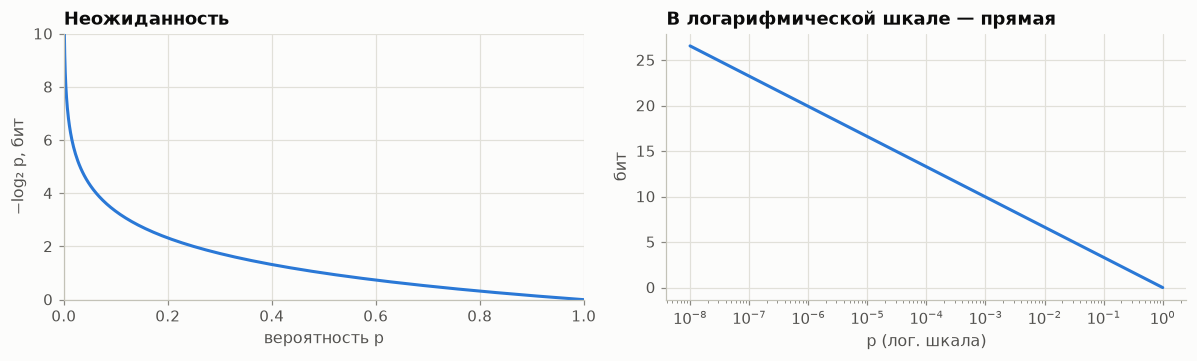

In [5]:
events = {"орёл": 1 / 2, "шестёрка": 1 / 6, "не шестёрка": 5 / 6, "туз": 1 / 13, "пиковый туз": 1 / 52,
          "лотерея 6 из 45": 1 / math.comb(45, 6), "ни одного выигрыша за 1000 попыток при 1 %": 0.99**1000}
for name, p in events.items():
    print(f"{name:42s} {-math.log2(p):7.3f} бит")
assert abs(-math.log2(1 / math.comb(45, 6)) - 22.957) < 1e-3 and abs(-1000 * math.log2(0.99) - 14.50) < 1e-2

ps = np.logspace(-8, 0, 200)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].plot(ps, -np.log2(ps), color=BLUE)
axes[0].set(xlim=(0, 1), ylim=(0, 10), xlabel="вероятность p", ylabel="−log₂ p, бит", title="Неожиданность")
axes[1].semilogx(ps, -np.log2(ps), color=BLUE)
axes[1].set(xlabel="p (лог. шкала)", ylabel="бит", title="В логарифмической шкале — прямая")
plt.tight_layout()
plt.show()

### Шаг 4. Цепочка фактов о карте: $I(x, y) = I(x) + I(y \mid x)$

In [6]:
RANKS = ["2", "3", "4", "5", "6", "7", "8", "9", "10", "В", "Д", "К", "Т"]
deck = [(r, s) for s in "♠♥♦♣" for r in RANKS]
facts = {"красная": lambda c: c[1] in "♥♦", "черви": lambda c: c[1] == "♥", "картинка": lambda c: c[0] in ("В", "Д", "К")}


def chain(order):
    cur, out = deck, []
    for key in order:
        nxt = [c for c in cur if facts[key](c)]
        out.append((key, math.log2(len(cur) / len(nxt))))
        cur = nxt
    return out, len(cur)


for order in (["красная", "черви", "картинка"], ["картинка", "черви", "красная"]):
    parts, left = chain(order)
    print(" → ".join(f"{k} ({v:.3f})" for k, v in parts), f"= {sum(v for _, v in parts):.3f} бит, осталось {left}")
    assert abs(sum(v for _, v in parts) - math.log2(52 / 3)) < 1e-12

красная (1.000) → черви (1.000) → картинка (2.115) = 4.115 бит, осталось 3
картинка (2.115) → черви (2.000) → красная (0.000) = 4.115 бит, осталось 3


## Блок 2. Энтропия

### Шаг 5. Энтропия — средняя неожиданность

In [7]:
table = {"монета": [.5, .5], "нечестная 0.9/0.1": [.9, .1], "кубик": [1 / 6] * 6, "½ ¼ ⅛ ⅛": [.5, .25, .125, .125],
         "город А": [.5, .25, .25], "город Б": [.9, .05, .05]}
for name, p in table.items():
    print(f"{name:18s} H = {H(p):.3f} бит; scipy: {stats.entropy(p, base=2):.3f}")
    assert abs(H(p) - stats.entropy(p, base=2)) < 1e-12
print("максимальный вклад −p log2 p при p = 1/e:", round(1 / (math.e * LN2), 3))

монета             H = 1.000 бит; scipy: 1.000
нечестная 0.9/0.1  H = 0.469 бит; scipy: 0.469
кубик              H = 2.585 бит; scipy: 2.585
½ ¼ ⅛ ⅛            H = 1.750 бит; scipy: 1.750
город А            H = 1.500 бит; scipy: 1.500
город Б            H = 0.569 бит; scipy: 0.569
максимальный вклад −p log2 p при p = 1/e: 0.531


### Шаг 6. Бинарная энтропия, вогнутость и группировка

h(смеси) = 1.000, среднее h групп = 0.469, разрыв = 0.531
h⁻¹(0.5) = 0.11
группировка A|BCD: 1.75  AB|CD: 1.75  H: 1.75
97 % + 3 × 1 %: 0.242 бита


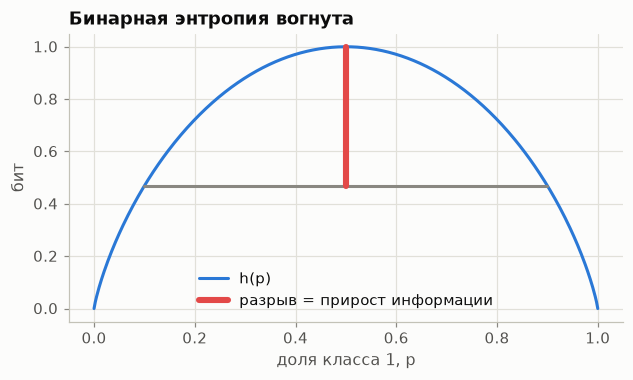

In [8]:
p1, p2, a = 0.9, 0.1, 0.5
pm = a * p1 + (1 - a) * p2
gap = h(pm) - (a * h(p1) + (1 - a) * h(p2))
print(f"h(смеси) = {h(pm):.3f}, среднее h групп = {a * h(p1) + (1 - a) * h(p2):.3f}, разрыв = {gap:.3f}")
assert abs(gap - 0.531) < 1e-3
print("h⁻¹(0.5) =", round(brentq(lambda e: h(e) - 0.5, 1e-9, 0.5), 4))
g1 = h(0.5) + 0.5 * h(0.5) + 0.25 * h(0.5)
g2 = h(0.75) + 0.75 * h(2 / 3) + 0.25 * h(0.5)
print("группировка A|BCD:", g1, " AB|CD:", round(g2, 12), " H:", H([.5, .25, .125, .125]))
assert abs(g1 - 1.75) < 1e-12 and abs(g2 - 1.75) < 1e-12
print("97 % + 3 × 1 %:", round(H([.97, .01, .01, .01]), 3), "бита")

xs = np.linspace(0, 1, 401)
fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.plot(xs, h(xs), color=BLUE, label="h(p)")
ax.plot([p2, p1], [h(p2), h(p1)], color=MUTED)
ax.plot([pm, pm], [h(p1), h(pm)], color=RED, lw=4, label="разрыв = прирост информации")
ax.set(xlabel="доля класса 1, p", ylabel="бит", title="Бинарная энтропия вогнута")
ax.legend()
plt.show()

### Шаг 7. Энтропия — среднее число вопросов

In [9]:
pets = [0.3, 0.25, 0.15, 0.1, 0.08, 0.06, 0.04, 0.02]
seq = [("1" * i + "0") if i < 7 else "1" * 7 for i in range(8)]
half = [format(i, "03b") for i in range(8)]
print(f"H = {H(pets):.3f}; по очереди {avg_len(pets, seq):.3f}; пополам {avg_len(pets, half):.3f}; Хаффман {avg_len(pets, huffman(pets)):.3f}")
assert (round(H(pets), 3), round(avg_len(pets, seq), 3), round(avg_len(pets, huffman(pets)), 3)) == (2.598, 2.83, 2.63)
uniform = [1 / 8] * 8
extreme = [0.86] + [0.02] * 7
print("равные шансы, по очереди:", avg_len(uniform, seq), "; почти всегда кошка: H =", round(H(extreme), 3), ", Хаффман", round(avg_len(extreme, huffman(extreme)), 3))
assert avg_len(uniform, seq) == 4.375 and abs(avg_len(extreme, huffman(extreme)) - 1.40) < 1e-9

H = 2.598; по очереди 2.830; пополам 3.000; Хаффман 2.630
равные шансы, по очереди: 4.375 ; почти всегда кошка: H = 0.977 , Хаффман 1.4


### Шаг 8. Перплексия

In [10]:
for name, p in {"½ ¼ ⅛ ⅛": [.5, .25, .125, .125], "90/5/5": [.9, .05, .05], "кубик": [1 / 6] * 6}.items():
    print(f"{name:10s} перплексия 2^H = {2 ** H(p):.3f}")
z = 1 / np.arange(1, 11)
z /= z.sum()
print("Ципф, k = 10, s = 1: 2^H =", round(2 ** H(z), 2))

½ ¼ ⅛ ⅛    перплексия 2^H = 3.364
90/5/5     перплексия 2^H = 1.483
кубик      перплексия 2^H = 6.000
Ципф, k = 10, s = 1: 2^H = 7.34


### Шаг 9. Энтропия по выборке: смещение и поправка Миллера — Мэдоу

Тот же опыт, что в виджете: 400 повторов, зерно 2026.

In [11]:
def entropy_sims(p, n, R=400, seed=2026):
    rng, cum = Mulberry32(seed), np.cumsum(p)
    plug, mm = [], []
    for _ in range(R):
        cnt = np.zeros(len(p), int)
        for _ in range(n):
            cnt[pick(cum, rng.random())] += 1
        f = cnt[cnt > 0] / n
        hh = -(f * np.log2(f)).sum()
        plug.append(hh)
        mm.append(hh + (len(f) - 1) / (2 * n * LN2))
    return np.array(plug), np.array(mm)


plug, mm = entropy_sims([1 / 8] * 8, 20)
print(f"8 равных исходов, n = 20: по частотам {plug.mean():.3f}, с поправкой {mm.mean():.3f} (истина 3)")
assert round(plug.mean(), 3) == 2.716 and round(mm.mean(), 3) == 2.948
plug32, mm32 = entropy_sims([1 / 32] * 32, 20)
print(f"32 равных исхода, n = 20: {plug32.mean():.3f} и {mm32.mean():.3f} (истина 5)")
assert round(plug32.mean(), 3) == 3.784

8 равных исходов, n = 20: по частотам 2.716, с поправкой 2.948 (истина 3)
32 равных исхода, n = 20: 3.784 и 4.288 (истина 5)


### Шаг 10. Максимальная энтропия: кубик Джейнса

In [12]:
faces = np.arange(1, 7)
mean_of = lambda lam: (faces * np.exp(lam * faces)).sum() / np.exp(lam * faces).sum()  # noqa: E731
lam = brentq(lambda t: mean_of(t) - 4.5, -30, 30)
p_me = np.exp(lam * faces)
p_me /= p_me.sum()
print(f"λ = {lam:.4f}; p = {p_me.round(3)}; H = {H(p_me):.3f} бит (два соседних — {H([.5, .5]):.0f}, равномерно на 3–6 — {H([.25] * 4):.0f})")
assert round(lam, 3) == 0.371 and round(H(p_me), 3) == 2.328

λ = 0.3710; p = [0.054 0.079 0.114 0.165 0.24  0.347]; H = 2.328 бит (два соседних — 1, равномерно на 3–6 — 2)


### Шаг 11. Дифференциальная энтропия и квантование

In [13]:
dists = {"нормальное": stats.norm(), "Лапласа": stats.laplace(scale=1 / np.sqrt(2)), "равномерное": stats.uniform(-np.sqrt(3), 2 * np.sqrt(3))}
for D in (0.25, 0.1):
    edges = np.arange(-7, 7 + D / 2, D)
    for name, d in dists.items():
        P = np.diff(d.cdf(edges))
        P = P[P > 0]
        hx = d.entropy() / LN2
        print(f"Δ = {D}: {name:12s} h = {hx:.3f}, H(X_Δ) = {-(P * np.log2(P)).sum():.3f}, h − log2 Δ = {hx - np.log2(D):.3f}")
assert abs(stats.norm().entropy() / LN2 - 2.047) < 1e-3

Δ = 0.25: нормальное   h = 2.047, H(X_Δ) = 4.051, h − log2 Δ = 4.047
Δ = 0.25: Лапласа      h = 1.943, H(X_Δ) = 3.949, h − log2 Δ = 3.943
Δ = 0.25: равномерное  h = 1.792, H(X_Δ) = 3.807, h − log2 Δ = 3.792
Δ = 0.1: нормальное   h = 2.047, H(X_Δ) = 5.370, h − log2 Δ = 5.369
Δ = 0.1: Лапласа      h = 1.943, H(X_Δ) = 5.265, h − log2 Δ = 5.265
Δ = 0.1: равномерное  h = 1.792, H(X_Δ) = 5.145, h − log2 Δ = 5.114


## Блок 3. Сжатие

### Шаг 12. Неравенство Крафта

In [14]:
for lens in ([1, 2, 3, 3], [1, 2, 2, 3], [2, 2, 2, 3], [1, 2, 3, 4, 4]):
    print(lens, "Σ 2^-l =", sum(2.0 ** -ln for ln in lens))

[1, 2, 3, 3] Σ 2^-l = 1.0
[1, 2, 2, 3] Σ 2^-l = 1.125
[2, 2, 2, 3] Σ 2^-l = 0.875
[1, 2, 3, 4, 4] Σ 2^-l = 1.0


### Шаг 13. Теорема Шеннона: код Шеннона и код Хаффмана

In [15]:
p = [.4, .3, .2, .1]
shannon = [math.ceil(-math.log2(q) - 1e-12) for q in p]
print(f"H = {H(p):.3f}; Шеннон {shannon} → {sum(a * b for a, b in zip(p, shannon)):.2f}; Хаффман {huffman(p)} → {avg_len(p, huffman(p)):.2f}")
assert abs(sum(a * b for a, b in zip(p, shannon)) - 2.4) < 1e-12 and abs(avg_len(p, huffman(p)) - 1.9) < 1e-12

H = 1.846; Шеннон [2, 2, 3, 4] → 2.40; Хаффман ['0', '10', '111', '110'] → 1.90


### Шаг 14. Алгоритм Хаффмана: несколько оптимальных деревьев

In [16]:
p = [.4, .2, .2, .1, .1]
for lens in ([2, 2, 2, 3, 3], [1, 2, 3, 4, 4]):
    m = sum(a * b for a, b in zip(p, lens))
    print(lens, "средняя длина", round(m, 3), "разброс", round(sum(a * (b - m) ** 2 for a, b in zip(p, lens)), 3))
print("наш Хаффман:", huffman(p), "; H =", round(H(p), 3), "; 99:1 →", round(H([.99, .01]), 3))

[2, 2, 2, 3, 3] средняя длина 2.2 разброс 0.16
[1, 2, 3, 4, 4] средняя длина 2.2 разброс 1.36
наш Хаффман: ['11', '00', '01', '100', '101'] ; H = 2.122 ; 99:1 → 0.081


### Шаг 15. Блочное кодирование и типичные последовательности

In [17]:
p1 = 0.1
rates = []
for n in range(1, 9):
    probs = [p1 ** sum(b) * (1 - p1) ** (n - sum(b)) for b in product((0, 1), repeat=n)]
    rates.append(avg_len(probs, huffman(probs)) / n)
print("L_n / n:", np.round(rates, 4), " H =", round(h(p1), 4))
assert [round(r, 3) for r in rates[:4]] == [1.0, 0.645, 0.533, 0.493]

n, eps = 100, 0.05
k = np.arange(n + 1)
v = -(k * np.log2(p1) + (n - k) * np.log2(1 - p1)) / n
typ = np.abs(v - h(p1)) <= eps
print(f"n = {n}: P(типичная) = {stats.binom.pmf(k[typ], n, p1).sum():.3f}; log2(всех типичных) ≈ {math.log2(sum(math.comb(n, int(j)) for j in k[typ])):.1f} из 100")
print("неожиданность последовательности из нулей:", round(-math.log2(0.9), 3), "бита на символ")

L_n / n: [1.     0.645  0.5327 0.4926 0.4802 0.4702 0.4743 0.4758]  H = 0.469
n = 100: P(типичная) = 0.382; log2(всех типичных) ≈ 47.2 из 100
неожиданность последовательности из нулей: 0.152 бита на символ


### Шаг 16. Сжатие текста: частоты и контекст

In [18]:
SAMPLE = ("Градиентный бустинг строит модель шаг за шагом. Каждое новое дерево исправляет ошибки предыдущих, и прогноз "
          "становится всё точнее. Теория информации объясняет, почему для классификации мы минимизируем именно log-loss: "
          "это средняя неожиданность правильных ответов для модели. Чем лучше модель предсказывает вероятности, тем меньше "
          "она удивляется и тем короче код, которым можно передать правильные ответы. Энтропия данных задаёт предел: ниже "
          "него не опустится ни одна модель, как бы долго мы ни обучали ансамбль.")


def text_stats(t):
    t = t.lower()
    n, cnt = len(t), Counter(t)
    p = [c / n for c in cnt.values()]
    pairs, prev = Counter(zip(t, t[1:])), Counter(t[:-1])
    H1 = -sum(c / (n - 1) * math.log2(c / prev[a]) for (a, _), c in pairs.items())
    return n, len(cnt), H(p), avg_len(p, huffman(p)), H1


n, m, H0, Lh, H1 = text_stats(SAMPLE)
print(f"символов {n}, разных {m}: log2 m = {math.log2(m):.2f}, H0 = {H0:.3f}, Хаффман = {Lh:.3f}, H1 = {H1:.3f}")
assert (n, m, round(H0, 2), round(H1, 2)) == (511, 41, 4.57, 2.96)
rng = Mulberry32(7)
chars = list(SAMPLE.lower())
rng.shuffle(chars)
print("перемешанный текст: H1 =", round(text_stats("".join(chars))[4], 3))
print("zlib:", round(8 * len(zlib.compress(SAMPLE.encode(), 9)) / n, 2), "бит/символ (на коротком тексте мешают заголовки и словарь)")

символов 511, разных 41: log2 m = 5.36, H0 = 4.574, Хаффман = 4.607, H1 = 2.957
перемешанный текст: H1 = 3.482
zlib: 7.25 бит/символ (на коротком тексте мешают заголовки и словарь)


## Блок 4. Две величины

### Шаг 17. Совместная и условная энтропия

In [19]:
J = np.array([[0.2, 0.05], [0.075, 0.675]])
HX, HY, HXY = H(J.sum(1)), H(J.sum(0)), H(J.ravel())
print(f"H(X) = {HX:.3f}, H(Y) = {HY:.3f}, H(X,Y) = {HXY:.3f}, H(Y|X) = {HXY - HX:.3f}, H(X|Y) = {HXY - HY:.3f}, I = {HX + HY - HXY:.3f}")
assert abs(HX + HY - HXY - 0.316) < 1e-3

H(X) = 0.811, H(Y) = 0.849, H(X,Y) = 1.344, H(Y|X) = 0.532, H(X|Y) = 0.495, I = 0.316


### Шаг 18. Взаимная информация: медицинский тест

In [20]:
def test_info(prev, sens=0.99, spec=0.95):
    J = np.array([[prev * sens, prev * (1 - sens)], [(1 - prev) * (1 - spec), (1 - prev) * spec]])
    return mi(J), J


I_dt, Jt = test_info(0.01)
post = Jt[0, 0] / Jt[:, 0].sum()
print(f"I(D;T) = {I_dt:.4f} бит при H(D) = {h(0.01):.4f}; P(болен|+) = {post:.3f}, H(D|T=+) = {h(post):.3f}")
print("sklearn (наты → биты):", round(mutual_info_score(None, None, contingency=Jt * 1e6) / LN2, 4))
assert abs(I_dt - 0.0407) < 1e-4 and abs(h(post) - 0.650) < 1e-3
for prev in (0.1, 0.5):
    print(f"распространённость {prev}: I = {test_info(prev)[0]:.3f}")

I(D;T) = 0.0407 бит при H(D) = 0.0808; P(болен|+) = 0.167, H(D|T=+) = 0.650
sklearn (наты → биты): 0.0407
распространённость 0.1: I = 0.329
распространённость 0.5: I = 0.815


### Шаг 19. Взаимная информация против корреляции

Данные виджета (зерно 19), оценка по 8 равночастотным корзинам и kNN-оценка scikit-learn.

In [21]:
def mi_data(kind, n=500, sd=0.1, seed=19):
    rng, X, Y = Mulberry32(seed), [], []
    for _ in range(n):
        if kind == "circle":
            t = rng.uniform(0, 2 * np.pi)
            e1, e2 = rng.normal(), rng.normal()
            X.append(np.cos(t) + sd * e1)
            Y.append(np.sin(t) + sd * e2)
        else:
            x = rng.uniform(-1, 1)
            e = sd * rng.normal()
            X.append(x)
            Y.append({"line": x + e, "parab": x * x + e, "exp": np.exp(3 * x) / 10 + e, "noise": 3 * e}[kind])
    return np.array(X), np.array(Y)


def rank_bins(v, b=8):
    r = np.empty(len(v), int)
    r[np.argsort(v, kind="stable")] = np.arange(len(v))
    return r * b // len(v)


def binned_mi(X, Y, b=8):
    T = np.zeros((b, b))
    np.add.at(T, (rank_bins(X, b), rank_bins(Y, b)), 1)
    return mi(T)


from sklearn.feature_selection import mutual_info_regression  # noqa: E402

for kind in ("line", "parab", "circle", "exp", "noise"):
    X, Y = mi_data(kind)
    knn = mutual_info_regression(X[:, None], Y, random_state=0)[0] / LN2
    print(f"{kind:7s} r = {np.corrcoef(X, Y)[0, 1]:+.3f}, I по корзинам = {binned_mi(X, Y):.3f}, kNN = {knn:.3f} бит")
X, Y = mi_data("parab")
assert round(binned_mi(X, Y), 3) == 1.202
X, Y = mi_data("exp")
assert binned_mi(X, Y) == binned_mi(X, np.exp(2 * Y))
print("экспонента: r до и после искажения:", round(np.corrcoef(X, Y)[0, 1], 3), round(np.corrcoef(X, np.exp(2 * Y))[0, 1], 3))

line    r = +0.986, I по корзинам = 1.904, kNN = 2.435 бит
parab   r = +0.035, I по корзинам = 1.202, kNN = 1.515 бит
circle  r = +0.004, I по корзинам = 0.832, kNN = 1.033 бит
exp     r = +0.818, I по корзинам = 1.263, kNN = 1.571 бит
noise   r = -0.010, I по корзинам = 0.061, kNN = 0.000 бит
экспонента: r до и после искажения: 0.818 0.569


### Шаг 20. Неравенство обработки данных: биннинг признака

In [22]:
NB = 25500
x = (np.arange(NB) + 0.5) / NB
for name, f in {"плавная": lambda t: 1 / (1 + np.exp(-10 * (t - 0.5))), "волны": lambda t: 0.5 + 0.4 * np.sin(6 * np.pi * t),
                "пик": lambda t: 0.1 + 0.8 * np.exp(-((t - 0.62) / 0.03) ** 2)}.items():
    p = f(x)
    I_xy = h(p.mean()) - h(p).mean()
    kept = []
    for b in (2, 4, 8, 32, 255):
        kb = np.minimum(b - 1, np.floor(x * b).astype(int))
        means = np.bincount(kb, p, b) / np.bincount(kb, None, b)
        kept.append(round(float(100 * (h(p.mean()) - (np.bincount(kb, None, b) / NB * h(means)).sum()) / I_xy), 2))
    print(f"{name:8s} I = {I_xy:.4f}; сохранено при b = 2, 4, 8, 32, 255: {kept} %")

плавная  I = 0.5389; сохранено при b = 2, 4, 8, 32, 255: [78.47, 93.42, 98.3, 99.89, 100.0] %
волны    I = 0.2551; сохранено при b = 2, 4, 8, 32, 255: [8.19, 8.19, 58.82, 96.78, 99.95] %
пик      I = 0.0873; сохранено при b = 2, 4, 8, 32, 255: [12.4, 32.86, 33.91, 91.65, 99.86] %


### Шаг 21. Синергия и избыточность

In [23]:
def two_features(rule, eps=0.0, copy=False):
    P = np.zeros((2, 2, 2))
    for a, b in product((0, 1), repeat=2):
        pab = (0.5 if a == b else 0.0) if copy else 0.25
        q = eps + (1 - 2 * eps) * rule(a, b)
        P[a, b] = pab * (1 - q), pab * q
    J12 = P.reshape(4, 2)
    return mi(P.sum(1)), mi(P.sum(0)), mi(J12[J12.sum(1) > 0])


for name, rule, copy in (("XOR", lambda a, b: a ^ b, False), ("AND", lambda a, b: a & b, False), ("копия", lambda a, b: a, True)):
    I1, I2, I12 = two_features(rule, copy=copy)
    print(f"{name:6s} I(x1;y) = {I1:.3f}, I(x2;y) = {I2:.3f}, вместе {I12:.3f}, вместе − сумма {I12 - I1 - I2:+.3f}")
print("XOR с шумом 0.1:", round(two_features(lambda a, b: a ^ b, 0.1)[2], 3), "= 1 − h(0.1) =", round(1 - h(0.1), 3))

XOR    I(x1;y) = 0.000, I(x2;y) = 0.000, вместе 1.000, вместе − сумма +1.000
AND    I(x1;y) = 0.311, I(x2;y) = 0.311, вместе 0.811, вместе − сумма +0.189
копия  I(x1;y) = 1.000, I(x2;y) = 1.000, вместе 1.000, вместе − сумма -1.000
XOR с шумом 0.1: 0.531 = 1 − h(0.1) = 0.531


### Шаг 22. Канал с шумом и код повторения

In [24]:
eps = 0.1
print("ёмкость C = 1 − h(0.1) =", round(1 - h(eps), 3))
for n in (1, 3, 5, 7):
    print(f"повтор ×{n}: скорость {1 / n:.3f}, ошибка {stats.binom.sf(n // 2, n, eps):.4f}")
assert abs(stats.binom.sf(1, 3, 0.1) - 0.028) < 1e-12

ёмкость C = 1 − h(0.1) = 0.531
повтор ×1: скорость 1.000, ошибка 0.1000
повтор ×3: скорость 0.333, ошибка 0.0280
повтор ×5: скорость 0.200, ошибка 0.0086
повтор ×7: скорость 0.143, ошибка 0.0027


## Блок 5. Перекрёстная энтропия и KL

### Шаг 23. Перекрёстная энтропия и неравенство Гиббса

In [25]:
p = np.array([.5, .25, .125, .125])
for q in (np.full(4, .25), p[::-1]):
    ce = -(p * np.log2(q)).sum()
    print(f"q = {q}: H(p,q) = {ce:.3f}, KL = {ce - H(p):.3f} = {stats.entropy(p, q, base=2):.3f}")
rng = Mulberry32(23)
worst = min(kl(a / a.sum(), b / b.sum()) for a, b in ((np.array([rng.random() for _ in range(5)]), np.array([rng.random() for _ in range(5)])) for _ in range(2000)))
print("наименьшая KL среди 2000 случайных пар распределений:", round(worst, 6), "≥ 0")
assert worst >= 0

q = [0.25 0.25 0.25 0.25]: H(p,q) = 2.000, KL = 0.250 = 0.250
q = [0.125 0.125 0.25  0.5  ]: H(p,q) = 2.625, KL = 0.875 = 0.875
наименьшая KL среди 2000 случайных пар распределений: 0.006177 ≥ 0


### Шаг 24. Несимметричность KL и неравенство треугольника

In [26]:
B = lambda t: [t, 1 - t]  # noqa: E731
print(f"KL(0.5||0.9) = {kl(B(.5), B(.9)):.3f}, KL(0.9||0.5) = {kl(B(.9), B(.5)):.3f}")
print(f"через 0.7: {kl(B(.5), B(.7)):.3f} + {kl(B(.7), B(.9)):.3f} = {kl(B(.5), B(.7)) + kl(B(.7), B(.9)):.3f} < {kl(B(.5), B(.9)):.3f}")
assert kl(B(.5), B(.7)) + kl(B(.7), B(.9)) < kl(B(.5), B(.9))

KL(0.5||0.9) = 0.737, KL(0.9||0.5) = 0.531
через 0.7: 0.126 + 0.222 = 0.347 < 0.737


### Шаг 25. Прямая и обратная KL при подгонке нормальной кривой к двум горбам

прямая: N(-0.00, 2.062²), KL(p||q) = 1.044 бит
обратная: N(2.00, 0.500²), KL(q||p) = 1.000 бит


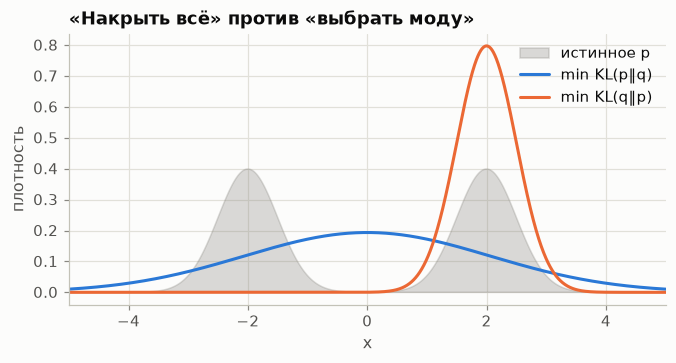

In [27]:
d, s0 = 2.0, 0.5
xg = np.linspace(-9, 9, 3601)
dx = xg[1] - xg[0]
pdens = 0.5 * stats.norm.pdf(xg, -d, s0) + 0.5 * stats.norm.pdf(xg, d, s0)
mu_f = (pdens * xg).sum() * dx
sd_f = math.sqrt((pdens * (xg - mu_f) ** 2).sum() * dx)
kl_f = np.sum(pdens * (np.log(pdens) - stats.norm.logpdf(xg, mu_f, sd_f))) * dx / LN2


def kl_rev(t):
    m, s = t[0], math.exp(t[1])
    q = stats.norm.pdf(xg, m, s)
    return np.sum(q * (stats.norm.logpdf(xg, m, s) - np.log(pdens + 1e-300))) * dx


r = minimize(kl_rev, [d, math.log(s0)], method="Nelder-Mead", options={"xatol": 1e-6, "fatol": 1e-10})
print(f"прямая: N({mu_f:.2f}, {sd_f:.3f}²), KL(p||q) = {kl_f:.3f} бит")
print(f"обратная: N({r.x[0]:.2f}, {math.exp(r.x[1]):.3f}²), KL(q||p) = {r.fun / LN2:.3f} бит")
assert abs(sd_f - 2.062) < 1e-3 and abs(r.fun / LN2 - 1.0) < 2e-3

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.fill_between(xg, pdens, color=MUTED, alpha=0.3, label="истинное p")
ax.plot(xg, stats.norm.pdf(xg, mu_f, sd_f), color=BLUE, label="min KL(p‖q)")
ax.plot(xg, stats.norm.pdf(xg, r.x[0], math.exp(r.x[1])), color=ORANGE, label="min KL(q‖p)")
ax.set(xlim=(-5, 5), xlabel="x", ylabel="плотность", title="«Накрыть всё» против «выбрать моду»")
ax.legend()
plt.show()

### Шаг 26. PSI = симметризованная KL

In [28]:
edges = stats.norm.ppf(np.linspace(0, 1, 11))
pb = np.full(10, 0.1)
for shift, scale in ((0.1, 1), (0.3, 1), (0.5, 1), (1, 1), (0, 2)):
    qb = np.diff(stats.norm.cdf((edges - shift) / scale))
    psi = np.sum((qb - pb) * np.log(qb / pb))
    kq = stats.entropy(qb, pb)
    print(f"сдвиг {shift}, масштаб {scale}: PSI = {psi:.4f} = {kq + stats.entropy(pb, qb):.4f}; TV = {0.5 * np.abs(qb - pb).sum():.4f} ≤ √(KL/2) = {math.sqrt(kq / 2):.4f}")
assert abs(np.sum((np.diff(stats.norm.cdf(edges - 0.3)) - pb) * np.log(np.diff(stats.norm.cdf(edges - 0.3)) / pb)) - 0.0861) < 1e-4

сдвиг 0.1, масштаб 1: PSI = 0.0096 = 0.0096; TV = 0.0398 ≤ √(KL/2) = 0.0489
сдвиг 0.3, масштаб 1: PSI = 0.0861 = 0.0861; TV = 0.1186 ≤ √(KL/2) = 0.1465
сдвиг 0.5, масштаб 1: PSI = 0.2377 = 0.2377; TV = 0.1974 ≤ √(KL/2) = 0.2428
сдвиг 1, масштаб 1: PSI = 0.9261 = 0.9261; TV = 0.3828 ≤ √(KL/2) = 0.4728
сдвиг 0, масштаб 2: PSI = 0.4908 = 0.4908; TV = 0.3217 ≤ √(KL/2) = 0.3610


### Шаг 27. Максимальное правдоподобие = минимум KL; сглаживание

Те же 300 выборок, что в виджете (зёрна 500…799).

In [29]:
P6 = np.array([0.35, 0.25, 0.18, 0.12, 0.07, 0.03])
cum6 = np.cumsum(P6)


def counts(n, seed):
    rng, c = Mulberry32(seed), np.zeros(6, int)
    for _ in range(n):
        c[pick(cum6, rng.random())] += 1
    return c


alphas = np.arange(61) * 0.05
for n in (20, 500):
    S = [counts(n, 500 + r) for r in range(300)]
    avg = np.array([np.mean([kl(P6, (c + a) / (n + 6 * a)) for c in S]) for a in alphas])
    best = alphas[int(np.argmin(avg))]
    print(f"n = {n}: средняя KL при α = 0: {avg[0]:.4f}, α = 1: {avg[20]:.4f}, лучшее α = {best:.2f} ({avg.min():.4f}); (k−1)/(2n ln 2) = {5 / (2 * n * LN2):.4f}")
print("выборка виджета (n = 20, зерно 3):", counts(20, 3))

n = 20: средняя KL при α = 0: inf, α = 1: 0.1247, лучшее α = 1.60 (0.1189); (k−1)/(2n ln 2) = 0.1803


n = 500: средняя KL при α = 0: 0.0073, α = 1: 0.0070, лучшее α = 2.00 (0.0069); (k−1)/(2n ln 2) = 0.0072
выборка виджета (n = 20, зерно 3): [8 5 5 2 0 0]


## Блок 6. Теория информации в бустинге

### Шаг 28. Log-loss — средняя неожиданность

In [30]:
y12 = np.array([1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0])
F12 = np.array([2.2, 1.5, 0.9, 0.4, -0.3, 1.8, -2.0, -1.2, -0.6, 0.3, -1.6, -2.4])
q12 = 1 / (1 + np.exp(-F12))
surprise = -np.log2(np.where(y12 == 1, q12, 1 - q12))
print(f"log-loss = {surprise.mean() * LN2:.4f} нат = {surprise.mean():.4f} бит; sklearn: {log_loss(y12, q12):.4f}")
assert abs(surprise.mean() * LN2 - log_loss(y12, q12)) < 1e-12
print("цена ошибки с логитом +6 при y = 0:", round(-math.log2(1 - 1 / (1 + math.exp(-6))), 2), "бита")

log-loss = 0.3434 нат = 0.4954 бит; sklearn: 0.3434
цена ошибки с логитом +6 при y = 0: 8.66 бита


### Шаг 29. Разложение: log-loss = H(Y|X) + KL

In [31]:
sig = lambda z: 1 / (1 + np.exp(-z))  # noqa: E731
xs = (np.arange(2000) + 0.5) / 2000
p_true = sig(10 * (xs - 0.5) - 0.8)
HY, HYX = h(p_true.mean()), h(p_true).mean()
for name, b, c in (("константа F0", 0, math.log(p_true.mean() / (1 - p_true.mean()))), ("идеальная", 10, -0.8), ("самоуверенная", 20, -0.8), ("робкая", 5, -0.8)):
    q = sig(b * (xs - 0.5) + c)
    ce = np.mean(-p_true * np.log2(q) - (1 - p_true) * np.log2(1 - q))
    print(f"{name:14s} log-loss = {ce:.3f}, KL = {ce - HYX:.3f}")
print(f"H(Y) = {HY:.3f}, H(Y|X) = {HYX:.3f}, I(X;Y) = {HY - HYX:.3f}")
assert (round(HY, 3), round(HYX, 3)) == (0.982, 0.458)

константа F0   log-loss = 0.982, KL = 0.524
идеальная      log-loss = 0.458, KL = 0.000
самоуверенная  log-loss = 0.587, KL = 0.129
робкая         log-loss = 0.549, KL = 0.091
H(Y) = 0.982, H(Y|X) = 0.458, I(X;Y) = 0.524


### Шаг 30. Бустинг в битах: от H(Y) к пределу и ниже

Данные виджета: обучение — зерно 7, новые данные — зерно 1007. Модель — `gbcourse.GradientBoosting`
(совпадает с веб-движком), сверка — `sklearn.ensemble.GradientBoostingClassifier`.

H(Y) = 0.953, предел H(Y|X) = 0.429; лучшее m = 30 (0.482); m = 60: 0.214 / 0.504; m = 300: 0.024 / 0.949

наибольшее расхождение кривых gbcourse и sklearn: 1.4210854715202004e-14


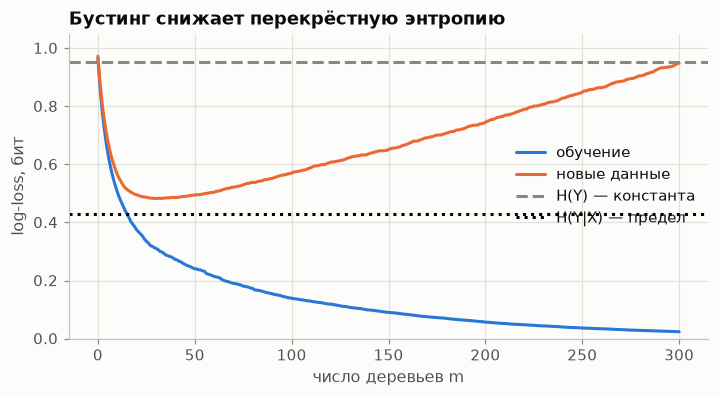

In [32]:
p_fun = lambda t: sig(4 * np.sin(3 * np.pi * t))  # noqa: E731


def bb_data(n, seed):
    rng, X, y = Mulberry32(seed), [], []
    for _ in range(n):
        t = rng.random()
        X.append([t])
        y.append(1 if rng.random() < p_fun(t) else 0)
    return np.array(X), np.array(y)


Xtr, ytr = bb_data(300, 7)
Xva, yva = bb_data(2000, 1007)
gb = GradientBoosting(loss="logistic", n_estimators=300, learning_rate=0.1, max_depth=3).fit(Xtr, ytr, eval_set=(Xva, yva))
tr = np.array(gb.history_["train"]) / LN2
va = np.array(gb.history_["eval"]) / LN2
grid = (np.arange(20000) + 0.5) / 20000
HY_b, floor = h(p_fun(grid).mean()), h(p_fun(grid)).mean()
print(f"H(Y) = {HY_b:.3f}, предел H(Y|X) = {floor:.3f}; лучшее m = {va.argmin()} ({va.min():.3f}); m = 60: {tr[60]:.3f} / {va[60]:.3f}; m = 300: {tr[300]:.3f} / {va[300]:.3f}")
assert va.argmin() == 30 and round(va.min(), 3) == 0.482 and tr[60] < floor

from sklearn.ensemble import GradientBoostingClassifier  # noqa: E402

sk = GradientBoostingClassifier(n_estimators=300, learning_rate=0.1, max_depth=3).fit(Xtr, ytr)
va_sk = np.array([log_loss(yva, pr[:, 1]) for pr in sk.staged_predict_proba(Xva)]) / LN2
print("наибольшее расхождение кривых gbcourse и sklearn:", np.abs(va_sk - va[1:]).max())

fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.plot(tr, color=BLUE, label="обучение")
ax.plot(va, color=ORANGE, label="новые данные")
ax.axhline(HY_b, color=MUTED, ls="--", label="H(Y) — константа")
ax.axhline(floor, color="k", ls=":", label="H(Y|X) — предел")
ax.set(xlabel="число деревьев m", ylabel="log-loss, бит", title="Бустинг снижает перекрёстную энтропию", ylim=(0, 1.05))
ax.legend()
plt.show()

### Шаг 31. Softmax, градиент q − t и сглаживание меток

In [33]:
z = np.array([2.0, 0.5, -1.0])
eps_ls = 0.1
t = np.full(3, eps_ls / 3)
t[0] += 1 - eps_ls
ce_fun = lambda zz: -(t * np.log(softmax(zz))).sum()  # noqa: E731
num = np.array([(ce_fun(z + 1e-6 * e) - ce_fun(z - 1e-6 * e)) / 2e-6 for e in np.eye(3)])
print("градиент численно:", num.round(6), " q − t:", (softmax(z) - t).round(6))
assert np.allclose(num, softmax(z) - t, atol=1e-8)
print("минимум потерь при q = t: H(t) =", round(H(t), 3), "бита; равные q: log2 3 =", round(math.log2(3), 3))

градиент численно: [-0.147736  0.141957  0.005779]  q − t: [-0.147736  0.141957  0.005779]
минимум потерь при q = t: H(t) = 0.42 бита; равные q: log2 3 = 1.585


### Шаг 32. Прирост информации = снижение log-loss; Ньютон первого дерева ∝ Джини

In [34]:
def split_data(seed):
    rng, pts = Mulberry32(seed), []
    for _ in range(40):
        xv = rng.uniform(0, 10)
        pr = 0.15 if xv < 3 else 0.75 if xv < 6.5 else 0.3
        pts.append((xv, 1 if rng.random() < pr else 0))
    pts.sort()
    return np.array([a for a, _ in pts]), np.array([b for _, b in pts])


def scores(x, y, thr):
    L, R = y[x <= thr], y[x > thr]
    n, p0 = len(y), y.mean()
    ig = h(p0) - len(L) / n * h(L.mean()) - len(R) / n * h(R.mean())
    pred = np.where(x <= thr, L.mean(), R.mean())
    dll = (log_loss(y, np.full(n, p0)) - log_loss(y, np.clip(pred, 1e-15, 1 - 1e-15))) / LN2
    gini = 2 * p0 * (1 - p0) - sum(len(c) / n * 2 * c.mean() * (1 - c.mean()) for c in (L, R))
    hs = p0 * (1 - p0)
    newton = 0.5 * sum((len(c) * p0 - c.sum()) ** 2 / (len(c) * hs) for c in (L, R))
    return ig, dll, gini, newton


for seed in (6, 53):
    x, y = split_data(seed)
    cands = (x[1:] + x[:-1]) / 2
    sc = np.array([scores(x, y, c) for c in cands])
    assert np.allclose(sc[:, 0], sc[:, 1], atol=1e-9)                                     # IG = Δ log-loss
    p0 = y.mean()
    assert np.allclose(sc[:, 3], len(y) * sc[:, 2] / (4 * p0 * (1 - p0)), atol=1e-9)     # Ньютон ∝ Джини
    t_ent, t_gini = cands[sc[:, 0].argmax()], cands[sc[:, 2].argmax()]
    tree_e = DecisionTreeClassifier(criterion="entropy", max_depth=1).fit(x[:, None], y)
    tree_g = DecisionTreeClassifier(criterion="gini", max_depth=1).fit(x[:, None], y)
    print(f"зерно {seed}: энтропия → {t_ent:.3f} (sklearn {tree_e.tree_.threshold[0]:.3f}), Джини/Ньютон → {t_gini:.3f} (sklearn {tree_g.tree_.threshold[0]:.3f}); IG = {sc[:, 0].max():.4f}")

try:
    import xgboost as xgb

    x, y = split_data(53)
    booster = xgb.XGBClassifier(n_estimators=1, max_depth=1, learning_rate=1.0, reg_lambda=0.0, min_child_weight=0.0,
                                tree_method="exact", base_score=float(y.mean())).fit(x[:, None], y)
    print("XGBoost, первое разбиение на зерне 53:", booster.get_booster().get_dump()[0].split("\n")[0], "→ порог Джини, а не энтропии")
except ImportError:
    print("xgboost не установлен — пропускаем сверку")

зерно 6: энтропия → 3.103 (sklearn 3.103), Джини/Ньютон → 3.103 (sklearn 3.103); IG = 0.2316
зерно 53: энтропия → 1.629 (sklearn 1.629), Джини/Ньютон → 3.104 (sklearn 3.104); IG = 0.1531


XGBoost, первое разбиение на зерне 53: 0:[f0<3.10375977] yes=1,no=2,missing=1 → порог Джини, а не энтропии


### Шаг 33. Признаки с множеством значений: прирост информации и gain ratio

Тот же опыт, что в виджете: n = 200, 200 повторов, зерно 233.

In [35]:
def gain(cat, y, K):
    cnt, ones = np.bincount(cat, minlength=K), np.bincount(cat, y, minlength=K)
    m = cnt > 0
    ig = h(y.mean()) - (cnt[m] / len(y) * h(ones[m] / cnt[m])).sum()
    split = -(cnt[m] / len(y) * np.log2(cnt[m] / len(y))).sum()
    return ig, ig / split


n, R = 200, 200
KS = [K for K in (2, 4, 8, 16, 32, 64, 128, 256, 512, 1000) if K <= n]
rng, res = Mulberry32(33 + n), {K: [] for K in KS}
for _ in range(R):
    xs_, ys_ = [], []
    for _ in range(n):
        a = 1 if rng.random() < 0.5 else 0
        xs_.append(a)
        ys_.append(a if rng.random() < 0.7 else 1 - a)
    xs_, ys_ = np.array(xs_), np.array(ys_)
    g_inf = gain(xs_, ys_, 2)
    for K in KS:
        res[K].append(gain(np.array([rng.randint(K) for _ in range(n)]), ys_, K) + g_inf)
for K in (8, 32, 64):
    r_ = np.array(res[K])
    print(f"k = {K:3d}: прирост шума {r_[:, 0].mean():.3f} (теория {(K - 1) / (2 * n * LN2):.3f}), полезного {r_[:, 2].mean():.3f}; "
          f"шум побеждает: по приросту {100 * (r_[:, 0] > r_[:, 2]).mean():.1f} %, по gain ratio {100 * (r_[:, 1] > r_[:, 3]).mean():.1f} %")
assert round(np.array(res[64])[:, 0].mean(), 3) == 0.276

k =   8: прирост шума 0.026 (теория 0.025), полезного 0.125; шум побеждает: по приросту 0.0 %, по gain ratio 0.0 %


k =  32: прирост шума 0.128 (теория 0.112), полезного 0.125; шум побеждает: по приросту 54.0 %, по gain ratio 0.0 %
k =  64: прирост шума 0.276 (теория 0.227), полезного 0.125; шум побеждает: по приросту 99.5 %, по gain ratio 1.0 %


### Шаг 34. Неравенство Фано

In [36]:
def fano(Hc, K):
    top = 1 - 1 / K
    f = lambda e: h(e) + e * math.log2(K - 1) - Hc  # noqa: E731
    return top if f(top) <= 0 else brentq(f, 1e-12, top)


print("K = 2, H = 0.5:", round(fano(0.5, 2), 4), "; шум 0.1:", round(fano(h(0.1), 2), 4), "; K = 10, H = 1 и 2:", round(fano(1, 10), 4), round(fano(2, 10), 4))
assert abs(fano(h(0.1), 2) - 0.1) < 1e-9

K = 2, H = 0.5: 0.11 ; шум 0.1: 0.1 ; K = 10, H = 1 и 2: 0.1352 0.3394


### Шаг 35. Минимальная длина описания

In [37]:
def mdl(key, n):
    f = {"ступенька": lambda t: 0.2 if t < 0.4 else 0.8, "плавная": lambda t: 1 / (1 + math.exp(-8 * (t - 0.5))),
         "волны": lambda t: 0.5 + 0.35 * math.sin(4 * math.pi * t)}[key]
    rng, X, y = Mulberry32(3), [], []
    for _ in range(n):
        t = rng.random()
        X.append(t)
        y.append(1 if rng.random() < f(t) else 0)
    X, y = np.array(X), np.array(y)
    G = (np.arange(4000) + 0.5) / 4000
    pG = np.array([f(t) for t in G])
    tot, test = [], []
    for k in range(1, 65):
        b = np.minimum(k - 1, (X * k).astype(int))
        cnt, ones = np.bincount(b, minlength=k), np.bincount(b, y, minlength=k)
        m = cnt > 0
        tot.append((cnt[m] * h(ones[m] / cnt[m])).sum() + 0.5 * k * math.log2(n))
        q = (ones + 0.5) / (cnt + 1)
        bg = np.minimum(k - 1, (G * k).astype(int))
        test.append(n * np.mean(-pG * np.log2(q[bg]) - (1 - pG) * np.log2(1 - q[bg])))
    return int(np.argmin(tot)) + 1, int(np.argmin(test)) + 1, np.array(test)


for key in ("ступенька", "плавная", "волны"):
    k_mdl, k_test, test = mdl(key, 500)
    print(f"{key:10s}: MDL выбирает k = {k_mdl}, новые данные — k = {k_test}; потеря от выбора MDL {test[k_mdl - 1] - test[k_test - 1]:.1f} бит на 500 объектов")

ступенька : MDL выбирает k = 5, новые данные — k = 5; потеря от выбора MDL 0.0 бит на 500 объектов
плавная   : MDL выбирает k = 6, новые данные — k = 14; потеря от выбора MDL 2.5 бит на 500 объектов
волны     : MDL выбирает k = 4, новые данные — k = 12; потеря от выбора MDL 9.4 бит на 500 объектов


### Шаг 36. Итог

| Где в бустинге | Понятие теории информации |
|---|---|
| log-loss, softmax | перекрёстная энтропия ответов и прогнозов |
| стартовый прогноз $F_0$ | лучшая константа, log-loss = $H(Y)$ |
| предел качества | $H(Y \mid X)$, выигрыш ≤ $I(X; Y)$, неравенство Фано |
| переобучение | обучающий log-loss ниже $H(Y \mid X)$, рост KL на новых данных |
| выбор разбиения | прирост информации = снижение log-loss; Ньютон первого дерева ∝ Джини |
| `max_bin` | неравенство обработки данных |
| λ, γ, сглаживание | регуляризация частот, минимальная длина описания |
| мониторинг сдвига | PSI = симметризованная KL |

## Упражнения

Условия — в `exercises/tasks.md`, решения — в `exercises/solutions.py`.